In [3]:
pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 8.4 MB/s eta 0:00:00


In [4]:
from nba_api.stats.endpoints import playergamelog

#FOR EXAMPLE : LET US TAKE STEPHEN CURRY

In [5]:
from nba_api.stats.static import players

players_list = players.get_players()

steph = [p for p in players_list if p['full_name'] == 'Stephen Curry'][0]

steph_id = steph['id']
print(steph_id)

201939


In [6]:
game_log=playergamelog.PlayerGameLog(player_id=steph_id,season='2024-25')
df=game_log.get_data_frames()[0]
df.head()

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22024,201939,0022401198,"Apr 13, 2025",GSW vs. LAC,L,38,10,20,0.500,...,2,3,6,2,0,8,2,36,-16,1
1,22024,201939,0022401183,"Apr 11, 2025",GSW @ POR,W,27,6,14,0.429,...,4,5,5,0,1,1,2,14,8,1
2,22024,201939,0022401163,"Apr 09, 2025",GSW vs. SAS,L,37,12,24,0.500,...,6,8,3,2,0,1,0,30,13,1
3,22024,201939,0022401154,"Apr 08, 2025",GSW @ PHX,W,26,9,17,0.529,...,8,9,6,1,1,2,0,25,31,1
4,22024,201939,0022401143,"Apr 06, 2025",GSW vs. HOU,L,33,1,10,0.100,...,2,2,8,0,0,4,0,3,-4,1


In [7]:
# Install first if needed:
# pip install nba_api

from nba_api.stats.static import players
from nba_api.stats.endpoints import playergamelog
import pandas as pd
import time


# Get all active NBA players
active_players = players.get_active_players()

print("Number of active players:", len(active_players))


# Seasons you want to collect
seasons = [
    '2019-20',
    '2020-21',
    '2021-22',
    '2022-23',
    '2023-24',
    '2024-25'
]


# Empty list to store all player data
all_players_data = []


# Loop through players
for player in active_players:

    player_id = player['id']
    player_name = player['full_name']

    for season in seasons:

        try:
            # Fetch player game logs
            game_log = playergamelog.PlayerGameLog(
                player_id=player_id,
                season=season
            )

            # Convert to dataframe
            df = game_log.get_data_frames()[0]

            # Add extra information
            df['PLAYER_NAME'] = player_name
            df['SEASON'] = season

            # Store dataframe
            all_players_data.append(df)

            print(f"Collected: {player_name} | {season}")

            # Prevent API overload
            time.sleep(0.6)


        except Exception as e:
            print(f"Skipped {player_name} | {season}")
            print(e)


# Combine all players
nba_data = pd.concat(
    all_players_data,
    ignore_index=True
)


# Save dataset
nba_data.to_csv(
    "nba_player_game_logs_2019_2025.csv",
    index=False
)


print("Dataset created successfully!")
print(nba_data.shape)
print(nba_data.head())

Number of active players: 530
Collected: Precious Achiuwa | 2019-20
Collected: Precious Achiuwa | 2020-21
Collected: Precious Achiuwa | 2021-22
Collected: Precious Achiuwa | 2022-23
Collected: Precious Achiuwa | 2023-24
Collected: Precious Achiuwa | 2024-25
Collected: Steven Adams | 2019-20
Collected: Steven Adams | 2020-21
Collected: Steven Adams | 2021-22
Collected: Steven Adams | 2022-23
Collected: Steven Adams | 2023-24
Collected: Steven Adams | 2024-25
Collected: Bam Adebayo | 2019-20
Collected: Bam Adebayo | 2020-21
Collected: Bam Adebayo | 2021-22
Collected: Bam Adebayo | 2022-23
Collected: Bam Adebayo | 2023-24
Collected: Bam Adebayo | 2024-25
Collected: Ochai Agbaji | 2019-20
Collected: Ochai Agbaji | 2020-21
Collected: Ochai Agbaji | 2021-22
Collected: Ochai Agbaji | 2022-23
Collected: Ochai Agbaji | 2023-24
Collected: Ochai Agbaji | 2024-25
Collected: Santi Aldama | 2019-20
Collected: Santi Aldama | 2020-21
Collected: Santi Aldama | 2021-22
Collected: Santi Aldama | 2022-23


/tmp/ipykernel_1772/1084339311.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  nba_data = pd.concat(


Dataset created successfully!
(98653, 29)
  SEASON_ID Player_ID     Game_ID     GAME_DATE      MATCHUP WL MIN FGM FGA  \
0     22020   1630173  0022001069  May 16, 2021    MIA @ DET  W  42  10  16   
1     22020   1630173  0022001062  May 15, 2021    MIA @ MIL  L   2   1   2   
2     22020   1630173  0022001050  May 13, 2021  MIA vs. PHI  W   2   0   0   
3     22020   1630173  0022000986  May 04, 2021  MIA vs. DAL  L   6   1   2   
4     22020   1630173  0022000969  May 02, 2021    MIA @ CHA  W   1   0   1   

   FG_PCT  ... AST STL  BLK TOV PF  PTS PLUS_MINUS VIDEO_AVAILABLE  \
0   0.625  ...   0   2    1   2  3   23          6               1   
1   0.500  ...   1   0    0   0  0    2          3               1   
2   0.000  ...   0   0    0   0  0    0         -5               1   
3   0.500  ...   1   0    1   0  0    2         12               1   
4   0.000  ...   0   0    0   0  0    0         -3               1   

        PLAYER_NAME   SEASON  
0  Precious Achiuwa  2020-21  


In [8]:
nba_data.to_csv("nba_player_game_logs.csv", index=False)

In [9]:
from google.colab import files

files.download("nba_player_game_logs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import pandas as pd
nba_data=pd.read_csv('nba_player_game_logs.csv')
nba_data.head()

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,PLAYER_NAME,SEASON
0,22020,1630173,22001069,"May 16, 2021",MIA @ DET,W,42,10,16,0.625,...,0,2,1,2,3,23,6,1,Precious Achiuwa,2020-21
1,22020,1630173,22001062,"May 15, 2021",MIA @ MIL,L,2,1,2,0.500,...,1,0,0,0,0,2,3,1,Precious Achiuwa,2020-21
2,22020,1630173,22001050,"May 13, 2021",MIA vs. PHI,W,2,0,0,0.000,...,0,0,0,0,0,0,-5,1,Precious Achiuwa,2020-21
3,22020,1630173,22000986,"May 04, 2021",MIA vs. DAL,L,6,1,2,0.500,...,1,0,1,0,0,2,12,1,Precious Achiuwa,2020-21
4,22020,1630173,22000969,"May 02, 2021",MIA @ CHA,W,1,0,1,0.000,...,0,0,0,0,0,0,-3,1,Precious Achiuwa,2020-21


In [11]:
nba_data.shape

(98653, 29)

In [12]:
nba_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98653 entries, 0 to 98652
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEASON_ID        98653 non-null  int64  
 1   Player_ID        98653 non-null  int64  
 2   Game_ID          98653 non-null  int64  
 3   GAME_DATE        98653 non-null  object 
 4   MATCHUP          98653 non-null  object 
 5   WL               98653 non-null  object 
 6   MIN              98653 non-null  int64  
 7   FGM              98653 non-null  int64  
 8   FGA              98653 non-null  int64  
 9   FG_PCT           98653 non-null  float64
 10  FG3M             98653 non-null  int64  
 11  FG3A             98653 non-null  int64  
 12  FG3_PCT          98653 non-null  float64
 13  FTM              98653 non-null  int64  
 14  FTA              98653 non-null  int64  
 15  FT_PCT           98653 non-null  float64
 16  OREB             98653 non-null  int64  
 17  DREB        

In [13]:
nba_data.isnull().sum()

,0
SEASON_ID,0
Player_ID,0
Game_ID,0
GAME_DATE,0
MATCHUP,0
WL,0
MIN,0
FGM,0
FGA,0
FG_PCT,0


In [14]:
nba_data.duplicated().sum()

np.int64(0)

In [15]:
features=["MIN","FGA","FG_PCT","FG3A","FG3_PCT","FTA","REB","AST","STL","BLK","TOV"]

In [16]:
X=nba_data[features]
y=nba_data['PTS']

In [17]:
X.head()

,MIN,FGA,FG_PCT,FG3A,FG3_PCT,FTA,REB,AST,STL,BLK,TOV
0,42,16,0.625,0,0.0,7,10,0,2,1,2
1,2,2,0.500,1,0.0,0,0,1,0,0,0
2,2,0,0.000,0,0.0,0,0,0,0,0,0
3,6,2,0.500,0,0.0,0,1,1,0,1,0
4,1,1,0.000,0,0.0,0,0,0,0,0,0


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print("Training features:",X_train.shape)
print("Training target:",y_train.shape)
print("Testing features:",X_test.shape)
print("Testing target:",y_test.shape)

Training features: (78922, 11)
Training target: (78922,)
Testing features: (19731, 11)
Testing target: (19731,)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [21]:
comparison=pd.DataFrame({'Actual Points':y_test,'Predicted Points':y_pred})
comparison.head(10)

,Actual Points,Predicted Points
96187,10,11.530672
8970,11,10.359272
5928,25,25.295211
23420,18,14.098850
48729,16,13.086359
44204,14,14.145866
6836,11,10.916769
97418,9,9.119626
13022,22,27.487435
25072,5,5.959786


In [22]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
import math
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)

Mean Squared Error: 6.924163236708907
Root Mean Squared Error: 2.631380481175025
R-squared: 0.920121865970937


In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,FG_PCT,9.427103
4,FG3_PCT,3.907441
1,FGA,1.010192
5,FTA,0.825530
3,FG3A,0.154387
9,BLK,0.054384
6,REB,0.014583
10,TOV,0.008368
7,AST,-0.001691
8,STL,-0.004759


In [24]:
nba_data=nba_data.sort_values(["PLAYER_NAME","GAME_DATE"])

In [25]:
nba_data['LAST_5_PTS_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['PTS'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))

In [26]:
nba_data[['PLAYER_NAME','GAME_DATE','PTS','LAST_5_PTS_AVERAGE']].head(15)

,PLAYER_NAME,GAME_DATE,PTS,LAST_5_PTS_AVERAGE
51625,A.J. Lawson,"Apr 01, 2025",13,NaN
51624,A.J. Lawson,"Apr 03, 2025",13,NaN
51582,A.J. Lawson,"Apr 04, 2024",0,NaN
51623,A.J. Lawson,"Apr 04, 2025",9,NaN
51581,A.J. Lawson,"Apr 05, 2024",0,NaN
51622,A.J. Lawson,"Apr 06, 2025",13,7.0
51563,A.J. Lawson,"Apr 07, 2023",12,7.0
51562,A.J. Lawson,"Apr 09, 2023",10,6.8
51580,A.J. Lawson,"Apr 09, 2024",2,8.8
51621,A.J. Lawson,"Apr 09, 2025",14,7.4


In [27]:
nba_model_data=nba_data.dropna(subset=["LAST_5_PTS_AVERAGE"])

In [28]:
nba_model_data.shape

(96863, 30)

#LAST 5 GAMES MINUTE AVERAGE

In [29]:
nba_model_data['LAST_5_MIN_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['MIN'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))

/tmp/ipykernel_1772/3438137113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_model_data['LAST_5_MIN_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['MIN'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))


#LAST 5 GAMES ASSIST AVERAGE

In [30]:
nba_model_data['LAST_5_AST_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['AST'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))

/tmp/ipykernel_1772/2261140399.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_model_data['LAST_5_AST_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['AST'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))


#LAST 5 GAMES REBOUNDS AVERAGE

In [31]:
nba_model_data['LAST_5_REB_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['REB'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))

/tmp/ipykernel_1772/3222637676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_model_data['LAST_5_REB_AVERAGE'] = (nba_data.groupby('PLAYER_NAME')['REB'].rolling(5).mean().shift(1).reset_index(level=0,drop=True))


In [32]:
features=["LAST_5_PTS_AVERAGE","LAST_5_MIN_AVERAGE","LAST_5_AST_AVERAGE","LAST_5_REB_AVERAGE"]

In [33]:
nba_model_data.columns

Index(['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE', 'PLAYER_NAME', 'SEASON',
       'LAST_5_PTS_AVERAGE', 'LAST_5_MIN_AVERAGE', 'LAST_5_AST_AVERAGE',
       'LAST_5_REB_AVERAGE'],
      dtype='object')

In [34]:
X=nba_model_data[features]
y=nba_model_data['PTS']

In [35]:
X.head()

,LAST_5_PTS_AVERAGE,LAST_5_MIN_AVERAGE,LAST_5_AST_AVERAGE,LAST_5_REB_AVERAGE
51622,7.0,12.0,1.4,2.6
51563,7.0,13.8,1.2,1.6
51562,6.8,14.8,0.4,2.2
51580,8.8,19.2,0.6,3.0
51621,7.4,15.4,0.4,2.4


In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [38]:
y_pred_lr=model.predict(X_test)

In [39]:
comparison_lr=pd.DataFrame({'Actual Points':y_test,'Predicted Points':y_pred_lr})
comparison_lr.head(10)

,Actual Points,Predicted Points
10590,17,6.792203
72539,8,9.979454
79555,18,23.015987
31988,12,12.929213
75801,13,14.240817
70950,24,8.393877
35315,5,6.090571
41502,15,8.003847
24122,15,10.387273
59758,14,14.433205


In [40]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import numpy as np
import math
mse=mean_squared_error(y_test,y_pred_lr)
mae=mean_absolute_error(y_test,y_pred_lr)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lr)

print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)
print("Mean Absolute Error:",mae)

Mean Squared Error: 50.38134702007051
Root Mean Squared Error: 7.09798189769955
R-squared: 0.39804425583775194
Mean Absolute Error: 5.538215642443754


#TAKING SEASON POINTS AVERAGE

In [41]:
nba_model_data['SEASON_AVG_POINTS'] = (nba_data.groupby(['PLAYER_NAME','SEASON'])['PTS'].transform("mean"))

/tmp/ipykernel_1772/222930300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_model_data['SEASON_AVG_POINTS'] = (nba_data.groupby(['PLAYER_NAME','SEASON'])['PTS'].transform("mean"))


#TAKING PREVIOUS GAME POINTS

In [42]:
nba_model_data['PREVIOUS_GAME_POINTS'] = (nba_data.groupby('PLAYER_NAME')['PTS'].shift(1))

/tmp/ipykernel_1772/3164094283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_model_data['PREVIOUS_GAME_POINTS'] = (nba_data.groupby('PLAYER_NAME')['PTS'].shift(1))


#LAST 5 GAMES AVERAGE FIELD GOAL ATTEMPTS

In [43]:
nba_model_data["LAST_5_FGA_AVG"] = (
    nba_model_data
    .groupby("PLAYER_NAME")["FGA"]
    .rolling(5)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

/tmp/ipykernel_1772/3585054956.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_model_data["LAST_5_FGA_AVG"] = (


In [44]:
features=["LAST_5_PTS_AVERAGE","LAST_5_MIN_AVERAGE","LAST_5_AST_AVERAGE","LAST_5_REB_AVERAGE","SEASON_AVG_POINTS","PREVIOUS_GAME_POINTS","LAST_5_FGA_AVG"]

In [45]:
X=nba_model_data[features]
y=nba_model_data['PTS']

In [46]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [48]:
nba_model_data=nba_model_data.dropna()

In [49]:
features=["LAST_5_PTS_AVERAGE","LAST_5_MIN_AVERAGE","LAST_5_AST_AVERAGE","LAST_5_REB_AVERAGE","SEASON_AVG_POINTS","PREVIOUS_GAME_POINTS","LAST_5_FGA_AVG"]

In [50]:
X=nba_model_data[features]
y=nba_model_data['PTS']

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


In [53]:
y_pred_lr_2=model.predict(X_test)

In [54]:
comparison_lr_2=pd.DataFrame({'Actual Points':y_test,'Predicted Points':y_pred_lr_2})
comparison_lr_2.head(10)

,Actual Points,Predicted Points
40162,0,4.091620
89998,5,6.020647
9090,8,7.283720
94638,15,17.267437
85974,8,6.231653
73244,11,5.700913
43334,21,22.433173
12945,25,20.409166
53448,6,15.640450
36666,7,7.673926


In [55]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import numpy as np
import math
mse=mean_squared_error(y_test,y_pred_lr_2)
mae=mean_absolute_error(y_test,y_pred_lr_2)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lr_2)

print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)
print("Mean Absolute Error:",mae)

Mean Squared Error: 37.63905572034915
Root Mean Squared Error: 6.13506770299637
R-squared: 0.5570136762230437
Mean Absolute Error: 4.7403814665296355


In [56]:
coefficients=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,SEASON_AVG_POINTS,0.945138
0,LAST_5_PTS_AVERAGE,0.034509
1,LAST_5_MIN_AVERAGE,0.022858
3,LAST_5_REB_AVERAGE,0.010876
2,LAST_5_AST_AVERAGE,0.009386
6,LAST_5_FGA_AVG,0.006564
5,PREVIOUS_GAME_POINTS,-0.002559


In [57]:
nba_model_data["SEASON_AVG_POINTS_BEFORE"] = (
    nba_model_data
    .groupby(["PLAYER_NAME", "SEASON"])["PTS"]
    .expanding()
    .mean()
    .shift(1)
    .reset_index(level=[0,1], drop=True)
)

In [58]:
nba_model_data = nba_model_data.dropna()

In [59]:
features = [
    "LAST_5_PTS_AVERAGE",
    "LAST_5_MIN_AVERAGE",
    "LAST_5_AST_AVERAGE",
    "LAST_5_REB_AVERAGE",
    "SEASON_AVG_POINTS_BEFORE",
    "PREVIOUS_GAME_POINTS",
    "LAST_5_FGA_AVG"
]

In [60]:
X=nba_model_data[features]
y=nba_model_data['PTS']

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [63]:
y_pred_lr_3=model.predict(X_test)

In [64]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import numpy as np
import math
mse=mean_squared_error(y_test,y_pred_lr_3)
mae=mean_absolute_error(y_test,y_pred_lr_3)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lr_3)

print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)
print("Mean Absolute Error:",mae)

Mean Squared Error: 41.44564913439346
Root Mean Squared Error: 6.437829535984427
R-squared: 0.5127291613077205
Mean Absolute Error: 4.98259066138562


In [65]:
comparison_lr_3=pd.DataFrame({'Actual Points':y_test,'Predicted Points':y_pred_lr_3})
comparison_lr_3.head(10)

,Actual Points,Predicted Points
40095,8,4.271935
89997,16,5.889546
9185,9,5.918560
94699,23,14.712891
19204,15,14.897417
30150,12,15.602901
53949,21,17.667107
17302,1,8.493659
53611,5,12.602353
36737,24,9.882317


In [66]:
coefficients=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,SEASON_AVG_POINTS_BEFORE,0.719186
6,LAST_5_FGA_AVG,0.203725
2,LAST_5_AST_AVERAGE,0.089960
0,LAST_5_PTS_AVERAGE,0.068166
3,LAST_5_REB_AVERAGE,0.042260
1,LAST_5_MIN_AVERAGE,0.018489
5,PREVIOUS_GAME_POINTS,-0.005804


In [67]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [68]:
y_pred_rf=rf_model.predict(X_test)

In [69]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import numpy as np
import math
mse=mean_squared_error(y_test,y_pred_rf)
mae=mean_absolute_error(y_test,y_pred_rf)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_rf)

print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)
print("Mean Absolute Error:",mae)

Mean Squared Error: 43.32995423048484
Root Mean Squared Error: 6.582549219754064
R-squared: 0.49057564353925
Mean Absolute Error: 5.103926270201754


In [70]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,SEASON_AVG_POINTS_BEFORE,0.588520
1,LAST_5_MIN_AVERAGE,0.077089
0,LAST_5_PTS_AVERAGE,0.073438
6,LAST_5_FGA_AVG,0.069551
3,LAST_5_REB_AVERAGE,0.068610
2,LAST_5_AST_AVERAGE,0.062028
5,PREVIOUS_GAME_POINTS,0.060765


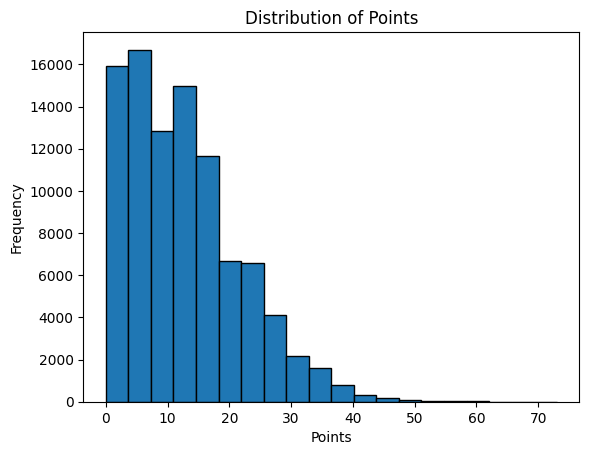

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(nba_model_data['PTS'], bins=20, edgecolor='k')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.title('Distribution of Points')
plt.show()

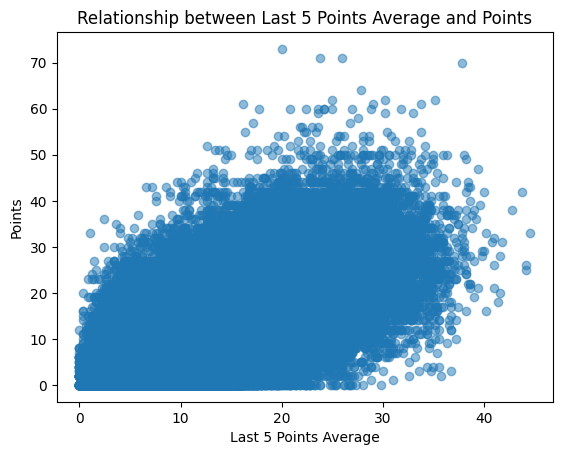

In [72]:
plt.scatter(nba_model_data['LAST_5_PTS_AVERAGE'], nba_model_data['PTS'], alpha=0.5)
plt.xlabel('Last 5 Points Average')
plt.ylabel('Points')
plt.title('Relationship between Last 5 Points Average and Points')
plt.show()

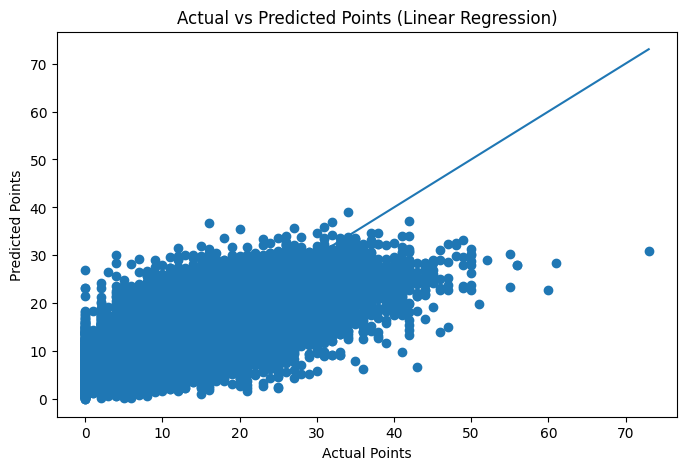

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Actual vs Predicted Points (Linear Regression)")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

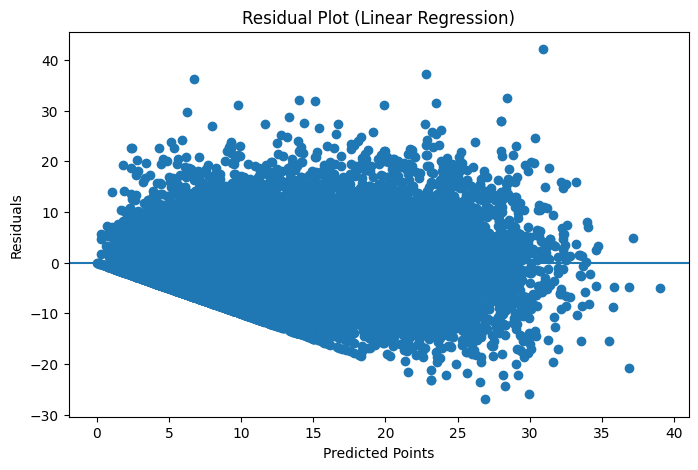

In [74]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Points")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")

plt.show()

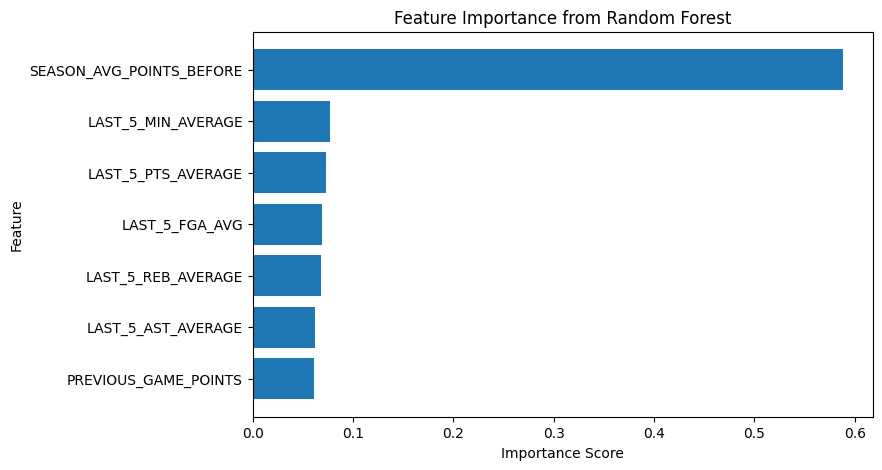

In [75]:
import pandas as pd
import matplotlib.pyplot as plt


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=True
)


plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance from Random Forest")

plt.show()

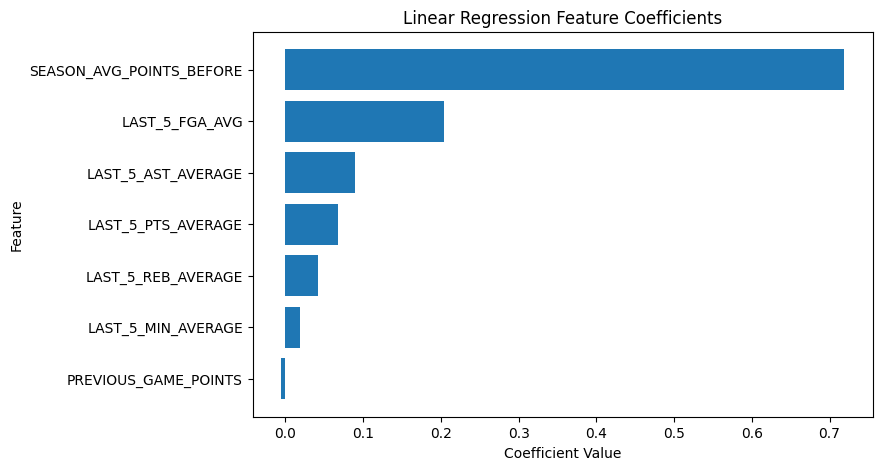

In [76]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})


coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=True
)


plt.figure(figsize=(8,5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")

plt.show()